In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from SysSimX.components.fmu_comp import FMUComponent

from OMPython import ModelicaSystem
from shutil import move

In [9]:
# Define paths and model names
pkg_file = Path.cwd().parent / 'Modelica/ControlledPendulum/package.mo'
pendulum_model_name = 'ControlledPendulum.Pendulum'

# Define solver options
euler_solver = "euler"
cvode_solver = "cvode"

# Build Modelica Systems and convert to FMUs
fmu_paths = {}
model = ModelicaSystem(str(pkg_file), pendulum_model_name, commandLineOptions=f"--fmiFlags=s:{cvode_solver}")
model.buildModel()
fmu_path = model.convertMo2Fmu(fmuType='cs')
dest_path = Path.cwd().parent / 'FMUs' / f"{pendulum_model_name.split('.')[-1]}.fmu"
move(fmu_path, dest_path)
fmu_paths[pendulum_model_name] = dest_path


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.




LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
Event 'wall_hit' detected between t=1.322 and t=1.323
Event 'wall_hit' d

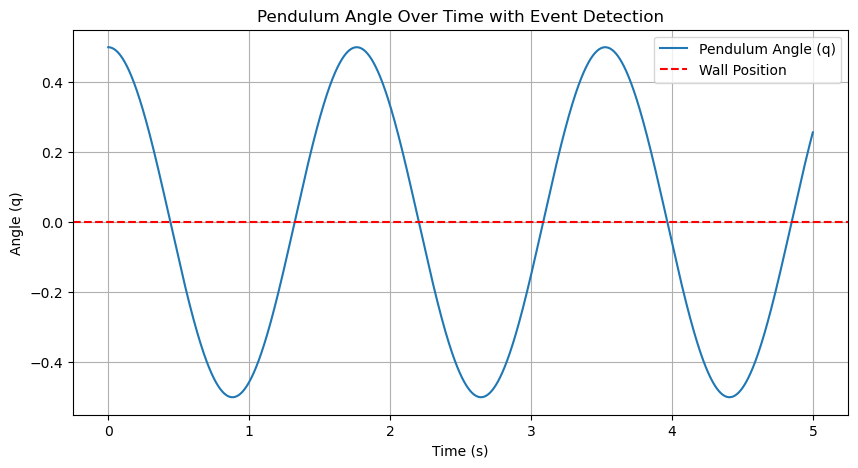

In [10]:
# Define event indicator function
def pendulum_wall_hit(comp: FMUComponent) -> float:
    q = comp.get_outputs()['q']
    return q

comp = FMUComponent('Pendulum', fmu_paths[pendulum_model_name])
comp.add_event_indicator('wall_hit', pendulum_wall_hit, direction=1)
comp.set_parameters(q0 = 0.5)
comp.initialize(t0=0.0)

sim_time = 5.0
dt = 0.001
time_points = []
q_points = []
t = 0.0
while t < sim_time:
    time_points.append(t)
    q = comp.get_outputs()['q']
    q_points.append(q)
    t_next = min(t + dt, sim_time)
    g_before = comp.evaluate_event_indicators()
    comp.do_step(t, t_next - t)
    g_after = comp.evaluate_event_indicators()
    # Check for events
    events = comp.detect_event_crossing(g_before, g_after)
    if events:
        for event_name in events:
            print(f"Event '{event_name}' detected between t={t:.3f} and t={t_next:.3f}")
    t = t_next

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(time_points, q_points, label='Pendulum Angle (q)')
plt.axhline(0.0, color='r', linestyle='--', label='Wall Position')
plt.title('Pendulum Angle Over Time with Event Detection')
plt.xlabel('Time (s)')
plt.ylabel('Angle (q)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from SysSimX.core.base import CoSimComponent
from typing import Callable, List, Dict

class EventLocator:
    def __init__(self, components: List[CoSimComponent],
                 max_iterations: int = 50,
                 tolerance: float = 1e-8):
        self.components = components
        self.max_iterations = max_iterations
        self.tolerance = tolerance

    
    